In [1]:
# external imports
from pathlib import Path

In [2]:
from primaite.network.generator import NetworkGenerator

In [3]:
# constants
NUMBER_OF_NODES = 30
RANDOM_SEED = 165116
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "hardcoded.yaml"
LAYDOWN_SAVE_PATH = Path("../data") / "laydown_configs" / "reeeee.yaml"
SERVICE_NAMES = ["HTTP", "SSH", "FTP"]
PORTS_LIST = ["80", "22", "21"]

The `random_internet_as_graph` from `networkx` generates an undirected graph resembling the Internet AS network.

Node Types:
* T  -> tier-1
* M  -> mid-level
* C  -> customer
* CP -> content-provider

Each edge models an ADV communication link with a type and customer attribute.

[Here are the docs](https://networkx.org/documentation/stable/reference/generated/networkx.generators.internet_as_graphs.random_internet_as_graph.html#random-internet-as-graph)


In [4]:
generator = NetworkGenerator(training_config_path=TRAINING_CONFIG_PATH, random_seed=1729, services=SERVICE_NAMES, ports=PORTS_LIST)

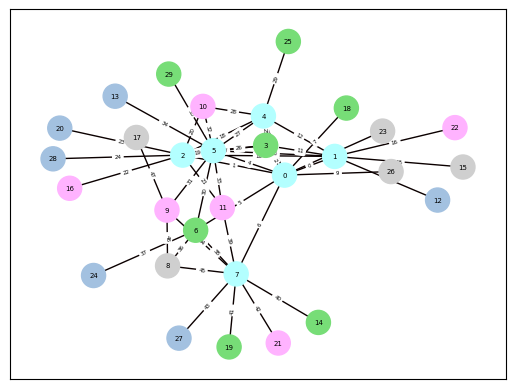

In [5]:
generator.show_network()

In [6]:
network = generator.network

In [7]:
network.nodes_table().head()

,Name,Hardware State,Software State,File System State,HTTP Service State,SSH Service State,FTP Service State
1,Node_0,ON,GOOD,GOOD,GOOD,GOOD,GOOD
2,Node_1,-,GOOD,GOOD,GOOD,GOOD,GOOD
3,Node_2,-,GOOD,GOOD,GOOD,GOOD,GOOD
4,Node_3,SHUTTING_DOWN,GOOD,GOOD,-,-,-
5,Node_4,-,GOOD,GOOD,GOOD,GOOD,GOOD


In [8]:
network.traffic_table().head()

,Name,HTTP Traffic,SSH Traffic,FTP Traffic
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0


In [9]:
network.serialize()

[{'item_type': 'PORTS',
  'ports_list': [{'port': '80'}, {'port': '22'}, {'port': '21'}]},
 {'item_type': 'SERVICES',
  'service_list': [{'name': 'HTTP'}, {'name': 'SSH'}, {'name': 'FTP'}]},
 {'item_type': 'NODE',
  'node_id': '0',
  'name': 'Node_0',
  'node_class': 'SERVICE',
  'node_type': 'SERVER',
  'priority': 'P2',
  'hardware_state': 'ON',
  'ip_address': '192.168.1.1',
  'software_state': 'GOOD',
  'file_system_state': 'GOOD',
  'services': [{'name': 'HTTP', 'port': '80', 'state': 'GOOD'},
   {'name': 'SSH', 'port': '22', 'state': 'GOOD'},
   {'name': 'FTP', 'port': '21', 'state': 'GOOD'}]},
 {'item_type': 'NODE',
  'node_id': '1',
  'name': 'Node_1',
  'node_class': 'SERVICE',
  'node_type': 'SERVER',
  'priority': 'P4',
  'hardware_state': 'NONE',
  'ip_address': '192.168.1.1',
  'software_state': 'GOOD',
  'file_system_state': 'GOOD',
  'services': [{'name': 'HTTP', 'port': '80', 'state': 'GOOD'},
   {'name': 'SSH', 'port': '22', 'state': 'GOOD'},
   {'name': 'FTP', 'port':

In [10]:
network.save(LAYDOWN_SAVE_PATH)